# İLERİ GÖRÜNTÜ İŞLEME  
## Final Ödevi  

---


 **Ad Soyad:** Egemen Gündüz  
 **Öğrenci Numarası:** 25281907  

---

### Konu

Bu projede gri uzay dönüşümü, tuz-biber gürültüsü oluşturma ve median filtreleme yöntemleri uygulanmıştır. Ayrıca yalnızca gürültülü pikseller üzerinde median filtre uygulanarak sonuçlar karşılaştırılmıştır.

---

### Kullanılan Teknolojiler

- Python  
- OpenCV  
- NumPy  
- Matplotlib  
- scikit-image  


In [72]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from skimage.util import random_noise

**BGR -> RGB dönüşümü yapmamızın sebebi matplotlib ile OpenCV kütüphanlerinin farklı renk formatlarında resmi okumasıdır.**

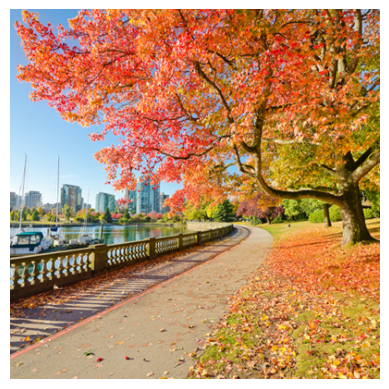

In [73]:
# aynı dizindeki resmi oku
img = cv2.imread("./nature.png")

# BGR -> RGB dönüşümü
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# göster
plt.imshow(img_rgb)
plt.axis("off")
plt.show()

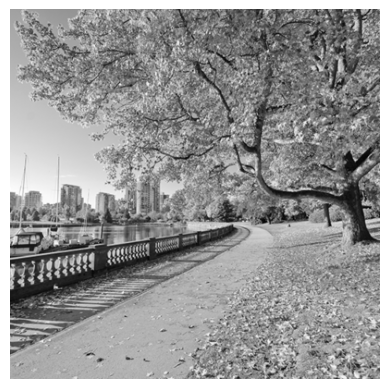

In [74]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

plt.imshow(gray, cmap="gray")
plt.axis("off")
plt.show()

### %2 Tuz & Biber Görüntüsü

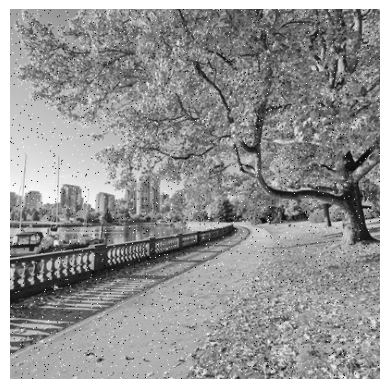

In [75]:
# %2 tuz & biber gürültüsü
noisy = random_noise(gray, mode='s&p', amount=0.02)

# göster
plt.imshow(noisy, cmap='gray')
plt.axis("off")
plt.show()

**Median Filtre uygulamadan önce piksellerin değerlerini 255 ile çarpmamızın sebebi değerlerin float olmasıdır**

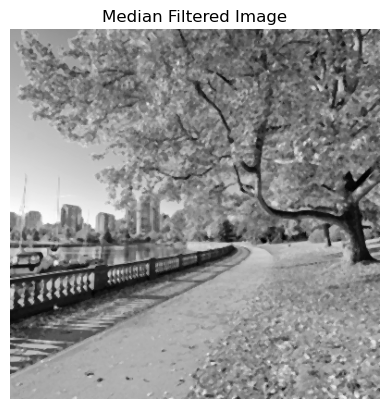

In [76]:
# noisy float ise uint8'e çevir
noisy_uint8 = (noisy * 255).astype(np.uint8)

# median filtre uygula
median_filtered = cv2.medianBlur(noisy_uint8, 3)

# kaydet
cv2.imwrite("./median_filtered.png", median_filtered)

# göster
plt.imshow(median_filtered, cmap="gray")
plt.title("Median Filtered Image")
plt.axis("off")
plt.show()

**Aşağıda, float -> uint8 dönüşümü yapıldıktan sonra resim içinde belirli bir bölgenin değerlerinin nasıl değiştiği gösterilmiştir** 

In [77]:
# küçük bölge(başka bir yer de seçilebilir)
crop_float = noisy[80:100, 80:100]
crop_uint8 = noisy_uint8[80:100, 80:100]

# dataframe formatı
df_float = pd.DataFrame(
    # yuvarlanmış
    np.round(crop_float, 3)
)

df_uint8 = pd.DataFrame(crop_uint8)

print("=== FLOAT64 FORMAT (0-1 aralığı) ===")
display(df_float)

print("\nVeri tipi:", crop_float.dtype)

print("\n=== UINT8 FORMAT (0-255 aralığı) ===")
display(df_uint8)

print("\nVeri tipi:", crop_uint8.dtype)

=== FLOAT64 FORMAT (0-1 aralığı) ===


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,0.435,0.475,0.482,0.286,0.263,0.314,0.290,0.447,0.635,0.659,0.569,0.573,0.361,0.412,0.541,0.475,0.553,0.690,0.718,0.522
1,0.647,0.655,0.522,0.345,0.400,0.443,0.510,0.725,0.855,0.749,0.604,0.510,0.396,0.361,0.490,0.000,0.584,0.667,0.612,0.529
2,0.706,0.678,0.525,0.565,0.537,0.427,0.596,0.792,0.855,0.769,0.639,0.557,0.475,0.451,0.553,0.549,0.541,0.000,0.529,0.447
3,0.514,0.525,0.451,0.412,0.557,0.482,0.529,0.722,1.000,0.678,0.694,0.706,0.561,0.561,0.651,0.553,0.471,0.361,0.337,0.443
4,0.490,0.451,0.427,0.514,0.498,0.576,0.537,0.588,0.373,0.573,0.694,0.675,0.576,0.565,0.545,0.486,0.400,0.522,0.549,0.573
5,0.396,0.463,0.506,0.694,0.620,0.627,0.482,0.576,0.627,0.678,0.675,0.592,0.467,0.525,0.690,0.545,0.408,0.506,0.514,0.561
6,0.388,0.439,0.510,0.624,0.643,0.675,0.592,0.576,0.659,0.663,0.525,0.573,0.580,0.525,0.675,0.667,0.584,0.557,0.502,0.000
7,0.333,0.435,0.396,0.533,0.710,0.616,0.569,0.455,0.478,0.549,0.616,0.675,0.690,0.592,1.000,0.655,0.592,0.600,0.541,0.490
8,0.498,0.573,0.443,0.749,0.859,0.624,0.561,0.537,0.514,0.561,0.671,0.592,0.612,0.690,0.753,0.718,0.667,0.678,0.631,0.494
9,0.671,0.502,0.475,0.831,0.690,0.565,0.643,0.557,0.000,0.741,0.624,0.522,0.580,0.718,0.757,0.729,0.671,0.655,0.686,0.549



Veri tipi: float64

=== UINT8 FORMAT (0-255 aralığı) ===


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,111,121,123,73,67,80,73,113,162,168,145,146,92,105,138,121,141,176,183,133
1,165,167,133,88,102,113,130,185,218,191,154,130,101,92,125,0,149,170,156,135
2,179,173,134,144,137,109,152,202,218,195,163,142,121,115,141,140,138,0,135,113
3,131,134,115,105,142,123,135,184,255,173,177,179,143,143,166,141,120,92,86,113
4,125,115,109,131,127,147,137,150,95,146,177,172,147,144,139,124,102,133,140,146
5,101,118,129,177,158,160,123,147,160,173,172,151,119,134,176,139,104,129,131,143
6,99,112,130,159,163,172,151,147,168,169,134,146,147,134,172,170,149,142,128,0
7,85,111,101,136,181,157,145,116,121,140,157,172,176,151,255,167,151,153,138,125
8,127,146,113,191,219,159,143,137,131,143,171,151,156,176,192,183,170,173,161,126
9,171,128,121,211,176,144,163,142,0,189,159,133,147,183,193,186,171,167,175,140



Veri tipi: uint8


In [78]:
# gürültülü pikseller
mask = (noisy_uint8 == 0) | (noisy_uint8 == 255)

In [79]:
median_filtered_only_noise = noisy_uint8.copy()

In [80]:
median_filtered_only_noise[mask] = cv2.medianBlur(noisy_uint8, 3)[mask]

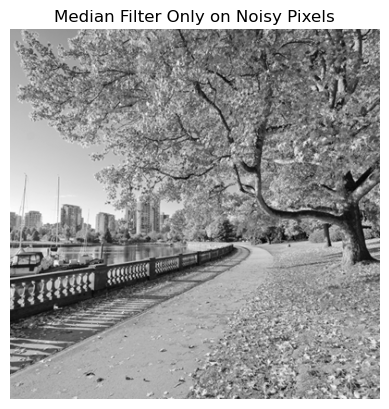

In [81]:
# kaydet
cv2.imwrite("./median_filtered_only_noise.png", median_filtered_only_noise)

# göster
plt.imshow(median_filtered_only_noise, cmap="gray")
plt.title("Median Filter Only on Noisy Pixels")
plt.axis("off")
plt.show()

### %10 Tuz & Biber Görüntüsü

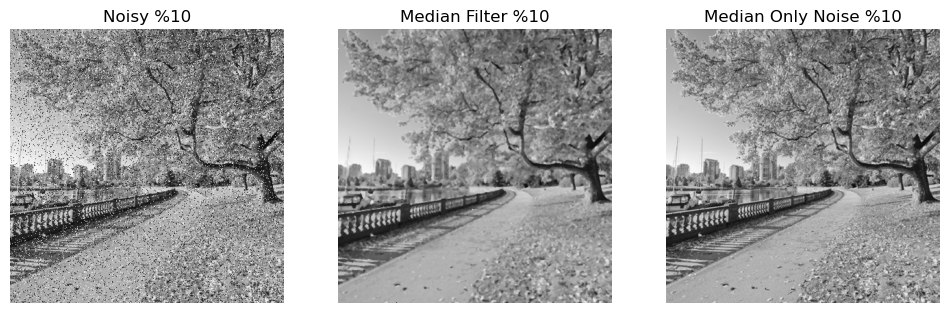

In [82]:
# %10 tuz-biber gürültüsü
noisy_10 = random_noise(gray, mode="s&p", amount=0.10)
noisy_uint8_10 = (noisy_10 * 255).astype(np.uint8)

# tüm görüntüye median filtre
median_filtered_10 = cv2.medianBlur(noisy_uint8_10, 3)

# sadece gürültülü piksellere median filtre
median_filtered_only_noise_10 = noisy_uint8_10.copy()

mask_10 = (noisy_uint8_10 == 0) | (noisy_uint8_10 == 255)

median_filtered_only_noise_10[mask_10] = \
cv2.medianBlur(noisy_uint8_10, 3)[mask_10]

# kaydet
cv2.imwrite("./median_filtered_10.png", median_filtered_10)
cv2.imwrite("./median_filtered_only_noise_10.png", median_filtered_only_noise_10)

# göster
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(noisy_uint8_10, cmap="gray")
plt.title("Noisy %10")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(median_filtered_10, cmap="gray")
plt.title("Median Filter %10")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(median_filtered_only_noise_10, cmap="gray")
plt.title("Median Only Noise %10")
plt.axis("off")

plt.show()

### %25 Tuz & Biber Görüntüsü

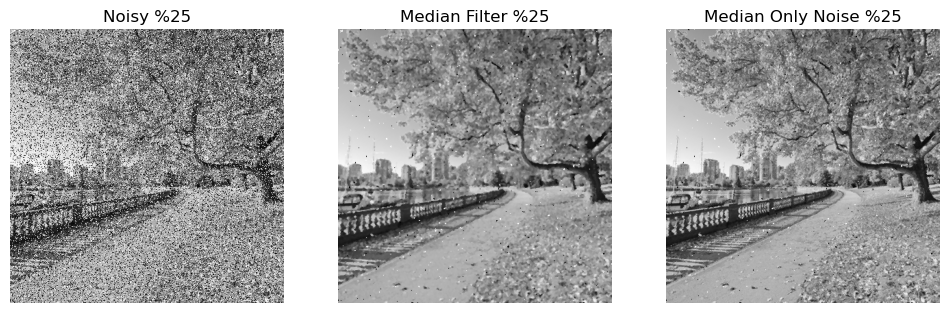

In [83]:
# %25 tuz-biber gürültüsü
noisy_25 = random_noise(gray, mode="s&p", amount=0.25)
noisy_uint8_25 = (noisy_25 * 255).astype(np.uint8)

# tüm görüntüye median filtre
median_filtered_25 = cv2.medianBlur(noisy_uint8_25, 3)

# sadece gürültülü piksellere median filtre
median_filtered_only_noise_25 = noisy_uint8_25.copy()

mask_25 = (noisy_uint8_25 == 0) | (noisy_uint8_25 == 255)

median_filtered_only_noise_25[mask_25] = \
cv2.medianBlur(noisy_uint8_25, 3)[mask_25]

# kaydet
cv2.imwrite("./median_filtered_25.png", median_filtered_25)
cv2.imwrite("./median_filtered_only_noise_25.png", median_filtered_only_noise_25)

# göster
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(noisy_uint8_25, cmap="gray")
plt.title("Noisy %25")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(median_filtered_25, cmap="gray")
plt.title("Median Filter %25")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(median_filtered_only_noise_25, cmap="gray")
plt.title("Median Only Noise %25")
plt.axis("off")

plt.show()

### Proje Açıklaması

Bu projede görüntü işleme alanında yaygın olarak kullanılan tuz-biber (salt & pepper) gürültüsü ve median filtreleme yöntemleri incelenmiştir. Çalışma boyunca bir görüntü üzerinde farklı oranlarda gürültü oluşturulmuş ve bu gürültüyü gidermek için median filtre uygulanmıştır. Ayrıca yalnızca bozulmuş pikseller üzerinde median filtre uygulanarak klasik median filtre yöntemi ile karşılaştırma yapılmıştır.

---

### 1. Görüntünün Gri Uzaya Dönüştürülmesi

İlk aşamada renkli görüntü OpenCV kullanılarak okunmuş ve gri uzaya dönüştürülmüştür.

Renkli görüntüler üç kanaldan oluşur:

- Red (Kırmızı)
- Green (Yeşil)
- Blue (Mavi)

Bu nedenle renkli görüntüler üç boyutlu veri yapısı şeklinde tutulur. Görüntü işleme işlemlerini daha sade ve hızlı gerçekleştirebilmek amacıyla görüntü gri uzaya dönüştürülmüştür. Gri görüntüler tek kanallıdır ve her piksel yalnızca parlaklık bilgisini içerir.

Bu işlem sırasında:

```python
cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
```

fonksiyonu kullanılmıştır.

---

### 2. Tuz-Biber Gürültüsü Eklenmesi

Gri görüntü üzerine farklı oranlarda tuz-biber gürültüsü eklenmiştir.

Tuz-biber gürültüsü:
- bazı piksellerin 0 değerine (siyah)
- bazı piksellerin 255 değerine (beyaz)

rastgele dönüştürülmesiyle oluşur.

Bu projede:
- %2
- %10
- %25

oranlarında gürültü oluşturulmuştur.

Gürültü eklemek için:

```python
random_noise(gray, mode="s&p", amount=...)
```

fonksiyonu kullanılmıştır.

Fonksiyon çıktısı `float64` veri tipinde ve 0-1 aralığında üretildiği için görüntü daha sonra OpenCV işlemlerine uygun hale getirilmek amacıyla:

```python
(noisy * 255).astype(np.uint8)
```

işlemi ile `uint8` formatına dönüştürülmüştür.

---

### 3. Median Filtre Uygulanması

Gürültülü görüntü üzerinde median filtre uygulanmıştır.

Median filtre:
- her pikselin komşuluk bölgesini inceler
- komşuluk içindeki piksel değerlerinin medyanını hesaplar
- merkezi pikseli bu değer ile değiştirir

Bu yöntem özellikle tuz-biber gürültüsünü gidermede oldukça etkilidir.

Median filtre şu fonksiyon ile uygulanmıştır:

```python
cv2.medianBlur(noisy_uint8, 3)
```

Buradaki:
- `3` değeri 3x3 filtre penceresini ifade etmektedir.

Filtre sonucunda oluşan görüntüler ayrıca dosya olarak kaydedilmiştir.

---

### 4. Median Filtrenin Sadece Gürültülü Pikseller Üzerinde Uygulanması

Projede ikinci bir yaklaşım olarak median filtre yalnızca bozulmuş pikseller üzerinde uygulanmıştır.

Bu yöntemde:
- yalnızca değeri `0` veya `255` olan pikseller gürültülü kabul edilmiştir
- diğer pikseller korunmuştur

Öncelikle gürültülü pikseller için bir maske oluşturulmuştur:

```python
mask = (noisy_uint8 == 0) | (noisy_uint8 == 255)
```

Daha sonra median filtre sonucu yalnızca bu pikseller üzerine uygulanmıştır:

```python
median_filtered_only_noise[mask] = cv2.medianBlur(noisy_uint8, 3)[mask]
```

Bu yaklaşımın amacı:
- gereksiz bulanıklaşmayı azaltmak
- görüntü detaylarını daha iyi korumaktır

Klasik median filtre tüm görüntü üzerinde çalışırken, bu yöntem yalnızca bozulmuş bölgeleri düzeltmektedir.

---

### 5. Farklı Gürültü Oranlarının Karşılaştırılması

Son aşamada:
- %2
- %10
- %25

gürültü oranları için aynı işlemler tekrar edilmiştir.

Bu sayede:
- gürültü arttıkça görüntü kalitesindeki değişim
- median filtrenin başarısı
- yalnızca gürültülü pikselleri filtreleme yönteminin performansı

karşılaştırılmıştır.

Özellikle yüksek gürültü oranlarında klasik median filtre görüntüyü daha fazla bulanıklaştırırken, yalnızca gürültülü pikselleri filtreleyen yaklaşım görüntü detaylarını daha iyi korumuştur.

---

### Kullanılan Kütüphaneler

Bu projede aşağıdaki Python kütüphaneleri kullanılmıştır:

- OpenCV
- NumPy
- Matplotlib
- scikit-image

Bu kütüphaneler sırasıyla:
- görüntü işleme
- matris işlemleri
- görselleştirme
- gürültü üretme

işlemleri için kullanılmıştır.

**Son olarak kaydedilen resimleri orijinal boyutlarında yeniden bastırıyorum.**


# Orijinal Görüntü

## 

**Dosya:** `nature.png`  
**Boyut:** 400 × 400


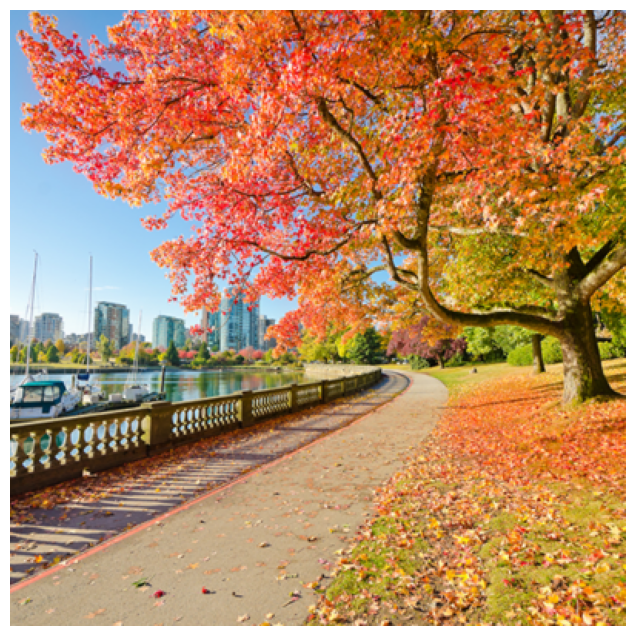


# %2 Gürültü Oranı

## Median Filter

**Dosya:** `median_filtered.png`  
**Boyut:** 400 × 400


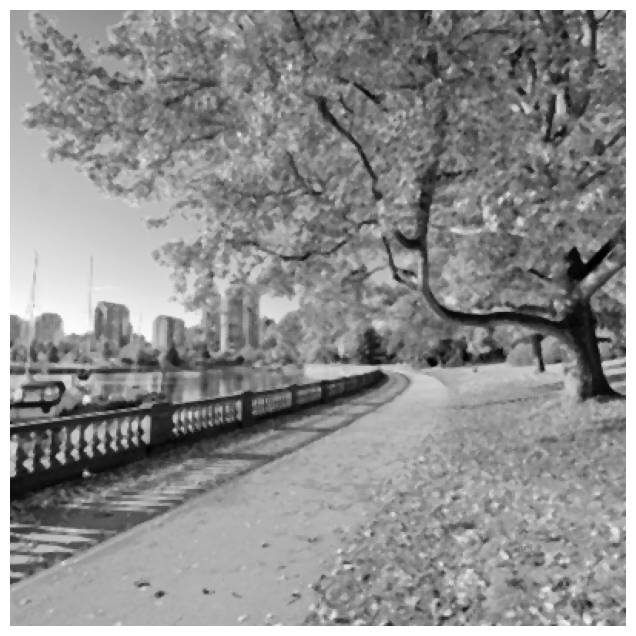


# %2 Gürültü Oranı

## Median Filtre Sadece Gürültülü Piksellere

**Dosya:** `median_filtered_only_noise.png`  
**Boyut:** 400 × 400


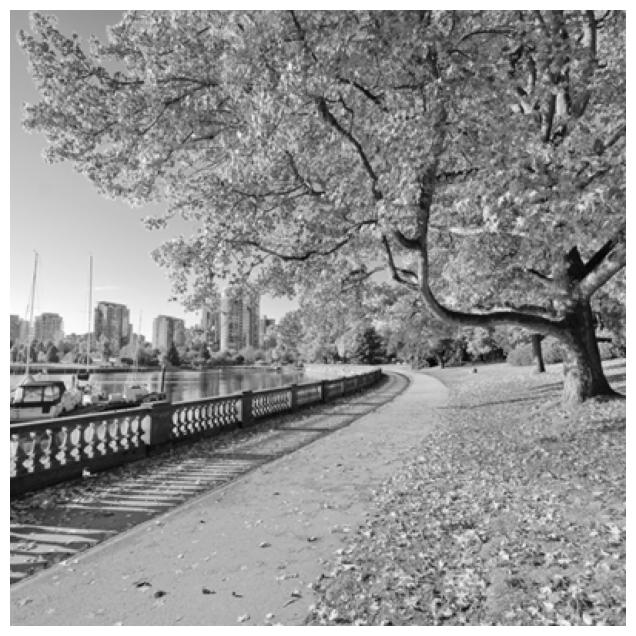


# %25 Gürültü Oranı

## Median Filter

**Dosya:** `median_filtered_25.png`  
**Boyut:** 400 × 400


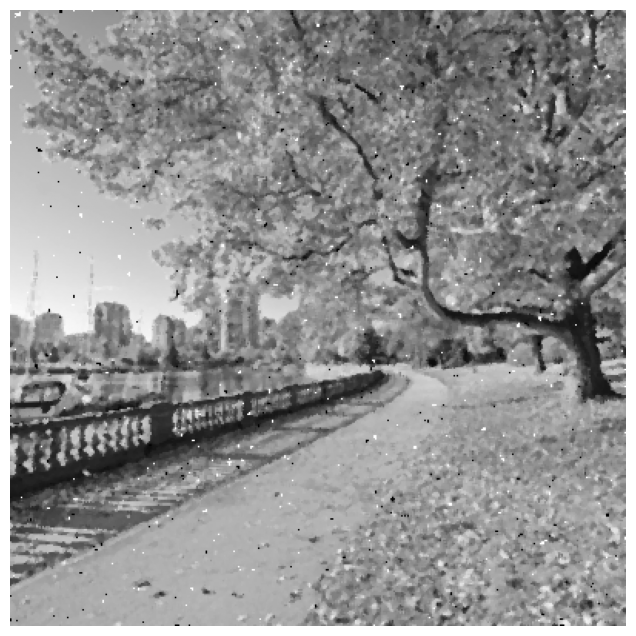


# %25 Gürültü Oranı

## Median Filtre Sadece Gürültülü Piksellere

**Dosya:** `median_filtered_only_noise_25.png`  
**Boyut:** 400 × 400


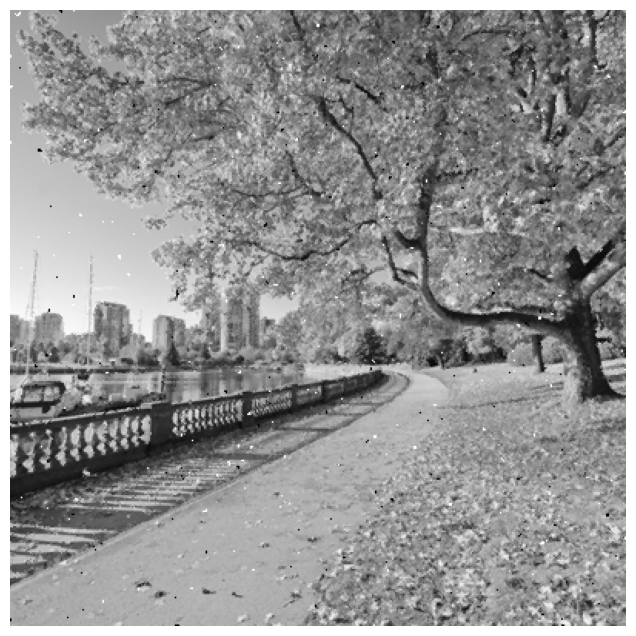


# %10 Gürültü Oranı

## Median Filter

**Dosya:** `median_filtered_10.png`  
**Boyut:** 400 × 400


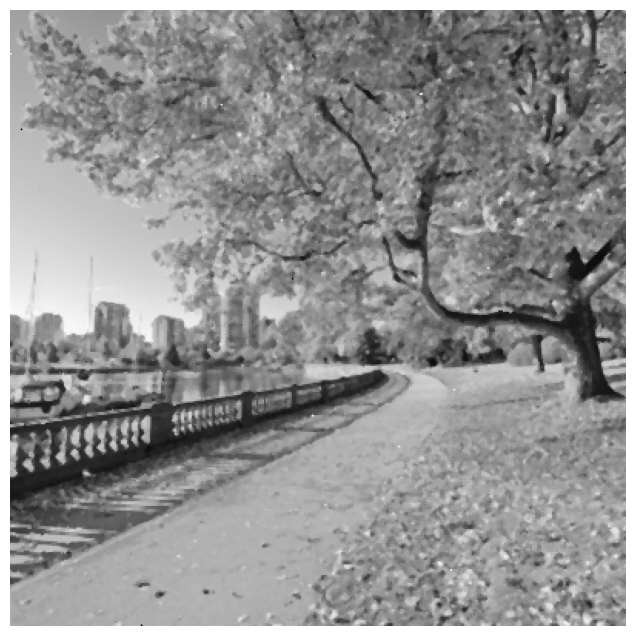


# %10 Gürültü Oranı

## Median Filtre Sadece Gürültülü Piksellere

**Dosya:** `median_filtered_only_noise_10.png`  
**Boyut:** 400 × 400


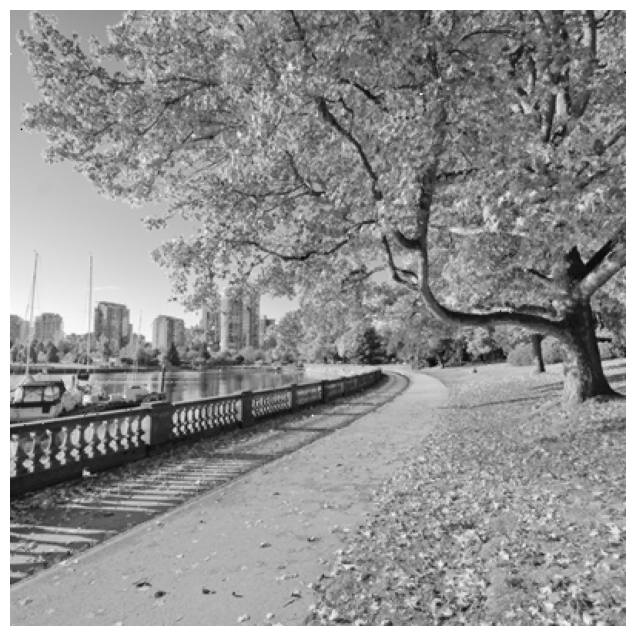

In [84]:
import os
from PIL import Image
from IPython.display import display, Markdown
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

image_files = sorted(
    [f for f in os.listdir(".") if f.endswith(".png")],
    key=lambda x: (
        x != "nature.png",
        "_10" in x,
        "_25" in x,
        "only_noise" in x,
        x
    )
)

for file in image_files:

    with Image.open(file) as img:
        width, height = img.size

    # başlık
    if file == "nature.png":
        title = "Orijinal Görüntü"

    elif "_10" in file:
        title = "%10 Gürültü Oranı"

    elif "_25" in file:
        title = "%25 Gürültü Oranı"

    else:
        title = "%2 Gürültü Oranı"

    # filtre tipi
    if "only_noise" in file:
        subtitle = "Median Filtre Sadece Gürültülü Piksellere"

    elif "median_filtered" in file:
        subtitle = "Median Filter"

    else:
        subtitle = ""

    display(Markdown(
        f"""
# {title}

## {subtitle}

**Dosya:** `{file}`  
**Boyut:** {width} × {height}
"""
    ))

    img = mpimg.imread(file)

    plt.figure(figsize=(8,8))
    plt.imshow(img, cmap="gray")
    plt.axis("off")
    plt.show()